In [1]:
from keras.optimizers import Adam
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, TerminateOnNaN, CSVLogger
from keras import backend as K
from keras.models import load_model
from math import ceil
import numpy as np
from matplotlib import pyplot as plt, patches
from sklearn.model_selection import train_test_split

from models.ssd7_custom import build_model
from loss_function.custom_loss import AOILoss
from custom_layers.GridCenters import GridCenters

from input_encoder_decoder.input_encoder import SSDInputEncoder
from input_encoder_decoder.output_decoder import decode_detections
from input_encoder_decoder.data_generator import DataGenerator

%matplotlib inline

In [2]:
img_height = 300 # Height of the input images
img_width = 300 # Width of the input images
img_channels = 3 # Number of color channels of the input images
intensity_mean = 127.5 # Set this to your preference (maybe `None`). The current settings transform the input pixel values to the interval `[-1,1]`.
intensity_range = 127.5 # Set this to your preference (maybe `None`). The current settings transform the input pixel values to the interval `[-1,1]`.
n_classes = 1 # Number of positive classes
normalize_coords = True # Whether or not the model is supposed to use coordinates relative to the image size

In [3]:
K.clear_session()

model = build_model(image_size=(img_height, img_width, img_channels),
                    n_classes=n_classes,
                    l2_regularization=0.0005,
                    normalize_coords=normalize_coords,
                    subtract_mean=intensity_mean,
                    divide_by_stddev=intensity_range)

adam = Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999, epsilon=1e-08, decay=0.0)

aoi_loss = AOILoss(neg_pos_ratio=3, alpha=1.0)

model.compile(optimizer=adam, loss=aoi_loss.compute_loss)

In [4]:
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_2 (InputLayer)           [(None, 300, 300, 3  0           []                               
                                )]                                                                
                                                                                                  
 identity_layer (Lambda)        (None, 300, 300, 3)  0           ['input_2[0][0]']                
                                                                                                  
 input_mean_normalization (Lamb  (None, 300, 300, 3)  0          ['identity_layer[1][0]']         
 da)                                                                                              
                                                                                              

In [5]:
predictor_size = [model.get_layer('classes4').output_shape[1:3]]
print(predictor_size)

encoder = SSDInputEncoder(img_height,
                          img_width,
                          n_classes,
                          predictor_sizes=predictor_size,
                          normalize_coords=True,
                          background_id=0)

generator = DataGenerator(parent_dir='/home/token/AOI_Project/Datasets/', encoder=encoder)

X, y = generator.get_data()

[(37, 37)]
Generating image arrays and encoding labels:
Converting images to arrays...


100%|██████████| 4000/4000 [00:01<00:00, 3072.35it/s]


Images as numpy:
(4000, 300, 300, 3)
Parsing ground truth labels from .csv


100%|██████████| 4000/4000 [00:03<00:00, 1159.47it/s]


Unencoded labels:
4000
Encoded labels:
(4000, 1369, 12)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

print('Train dataset: ', X_train.shape)
print('Test dataset: ', X_test.shape)
print('Train labels: ', y_train.shape)
print('Test labels: ', y_test.shape)

Train dataset:  (2800, 300, 300, 3)
Test dataset:  (1200, 300, 300, 3)
Train labels:  (2800, 1369, 12)
Test labels:  (1200, 1369, 12)


In [7]:
model_checkpoint = ModelCheckpoint(filepath='checkpoints/ssd7_epoch-{epoch:02d}_loss-{loss:.4f}_val_loss-{val_loss:.4f}.h5',
                                   monitor='val_loss',
                                   verbose=1,
                                   save_best_only=True,
                                   save_weights_only=False,
                                   mode='auto',
                                   save_freq="epoch")

csv_logger = CSVLogger(filename='ssd7_training_log.csv',
                       separator=',',
                       append=True)

early_stopping = EarlyStopping(monitor='val_loss',
                               min_delta=0.0,
                               patience=16,
                               verbose=1,
                               restore_best_weights=True)

reduce_learning_rate = ReduceLROnPlateau(monitor='loss',
                                         factor=0.2,
                                         patience=8,
                                         verbose=1,
                                         min_delta=0.001,
                                         cooldown=0,
                                         min_lr=0.00001)

callbacks = [model_checkpoint,
             csv_logger,
             early_stopping,
             reduce_learning_rate]

In [8]:
batch_size = 32
initial_epoch   = 0
final_epoch     = 200
steps_per_epoch = 1000

history = model.fit(X_train,
                    y_train,
                    batch_size=batch_size,
                    # steps_per_epoch=steps_per_epoch,
                    epochs=final_epoch,
                    callbacks=callbacks,
                    validation_data=(X_test, y_test),
                    validation_steps=ceil(X_test.shape[0]/batch_size),
                    initial_epoch=initial_epoch)

Epoch 1/200
88/88 [==============================] - ETA: 0s - loss: 6.0499
Epoch 1: val_loss improved from inf to 4.61025, saving model to checkpoints/ssd7_epoch-01_loss-6.0499_val_loss-4.6102.h5
88/88 [==============================] - 14s 131ms/step - loss: 6.0499 - val_loss: 4.6102 - lr: 0.0010
Epoch 2/200
88/88 [==============================] - ETA: 0s - loss: 0.8070
Epoch 2: val_loss improved from 4.61025 to 2.72213, saving model to checkpoints/ssd7_epoch-02_loss-0.8070_val_loss-2.7221.h5
88/88 [==============================] - 10s 119ms/step - loss: 0.8070 - val_loss: 2.7221 - lr: 0.0010
Epoch 3/200
88/88 [==============================] - ETA: 0s - loss: 0.6705
Epoch 3: val_loss improved from 2.72213 to 1.78762, saving model to checkpoints/ssd7_epoch-03_loss-0.6705_val_loss-1.7876.h5
88/88 [==============================] - 10s 119ms/step - loss: 0.6705 - val_loss: 1.7876 - lr: 0.0010
Epoch 4/200
88/88 [==============================] - ETA: 0s - loss: 0.6169
Epoch 4: val_los

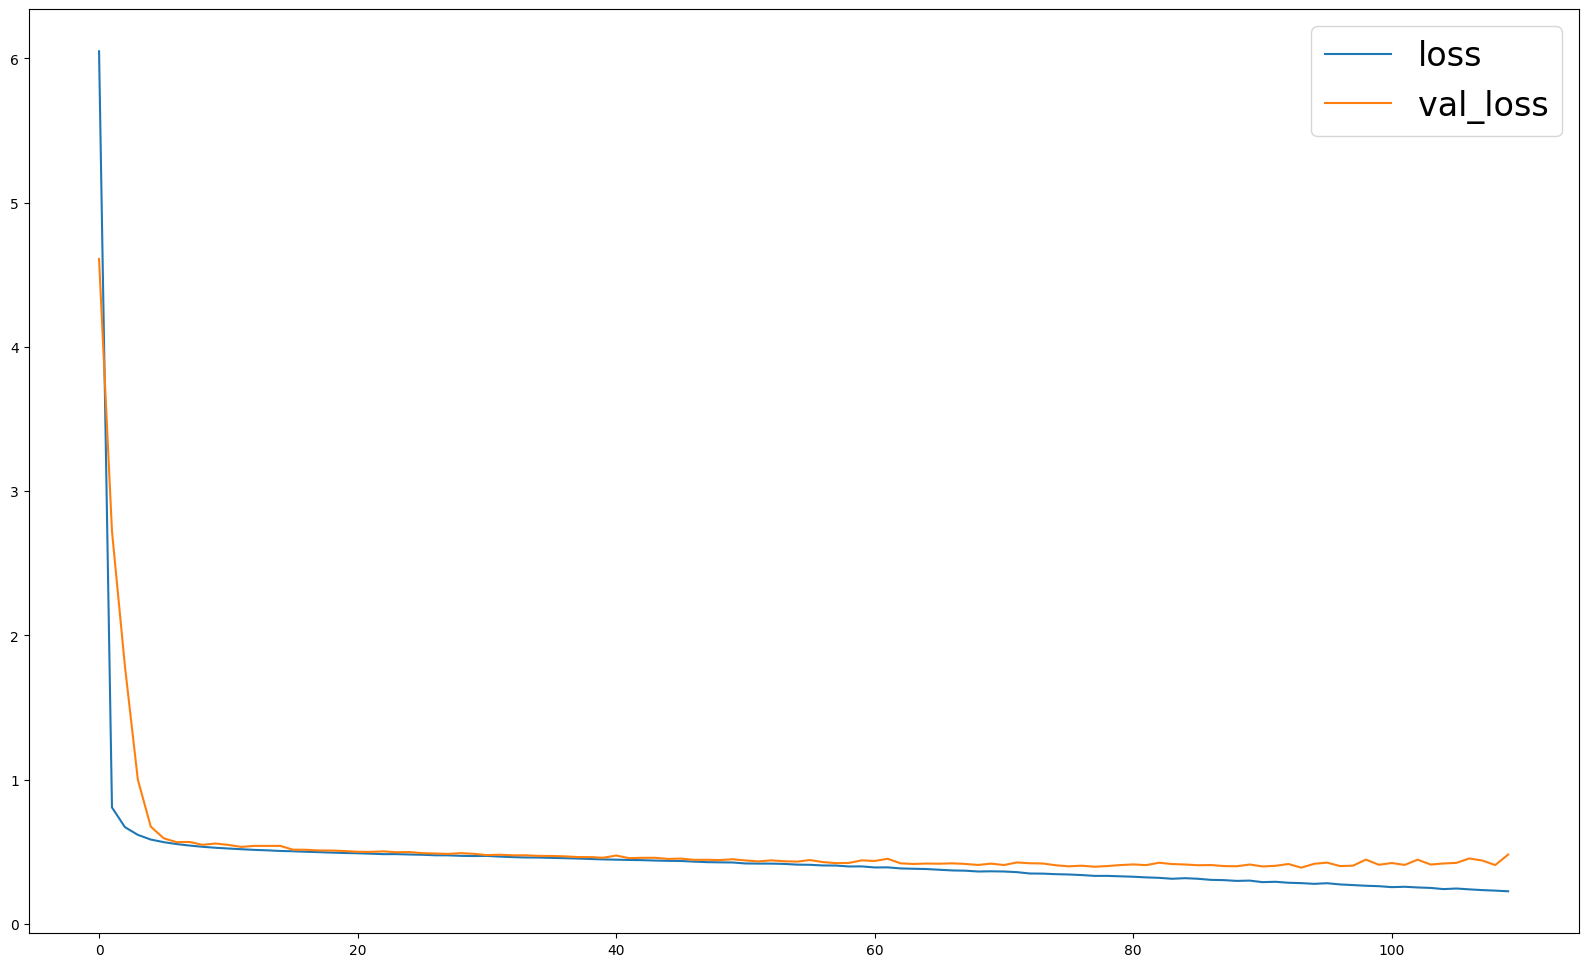

In [9]:
plt.figure(figsize=(20,12))
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend(loc='upper right', prop={'size': 24});

In [10]:
predictions = model.predict(X_test[:50])
print(predictions.shape)

2/2 [==============================] - 0s 98ms/step
(50, 1369, 12)


In [11]:
decoded_pred = decode_detections(predictions, img_height=img_height, img_width=img_width)
print(decoded_pred[0])

[[  1.           0.98892933  49.69578      2.9059365   76.50569
   24.220236    53.514076    25.584852    60.08665     35.182564  ]
 [  1.           0.8458938  118.82119     82.86554    143.98578
   68.148705   137.17108    107.092995   143.59451     91.76636   ]
 [  1.           0.53924793 134.2133     188.3937     167.06747
  179.4178     153.75491    217.03036    170.40181    209.3532    ]
 [  1.           0.55418974 137.59354    190.62244    176.52422
  188.85216    155.81349    207.37485    164.09674    206.87788   ]]


In [12]:
decoded_labels = decode_detections(y_test, img_height=img_height, img_width=img_width)
print(decoded_labels[0])

[[  1.   1.  57.   2.  79.  11.  48.  24.  70.  33.]
 [  1.   1. 180.  19. 202.  28. 171.  41. 193.  50.]
 [  1.   1. 136.  72. 149.  92. 116.  85. 129. 105.]
 [  1.   1. 145. 183. 169. 182. 146. 207. 170. 206.]]


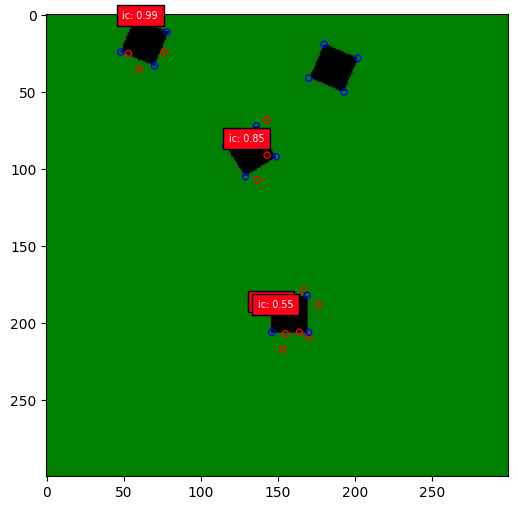

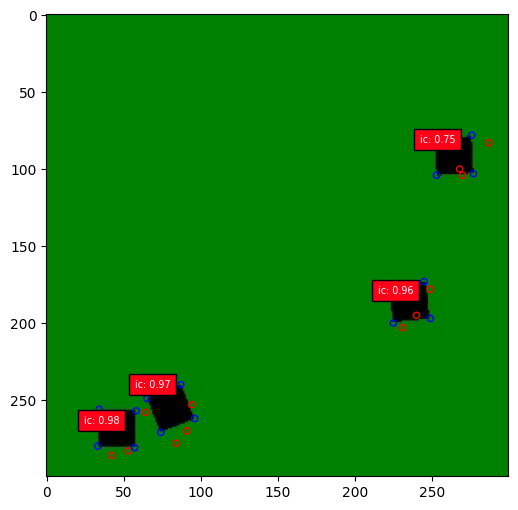

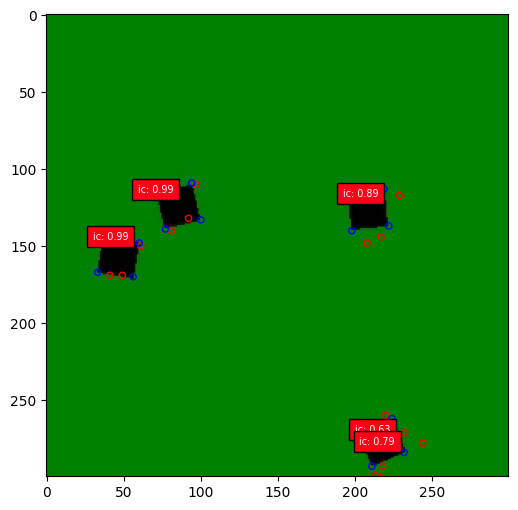

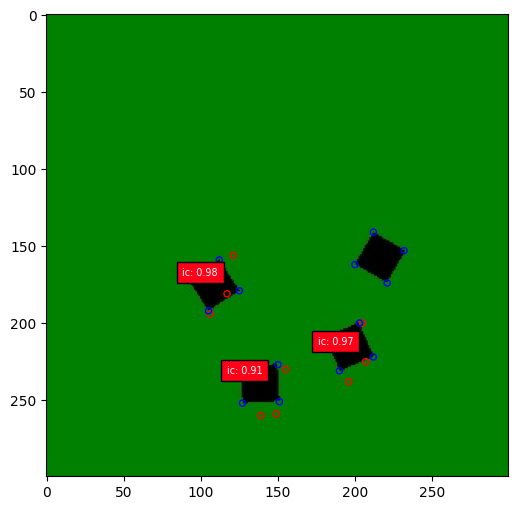

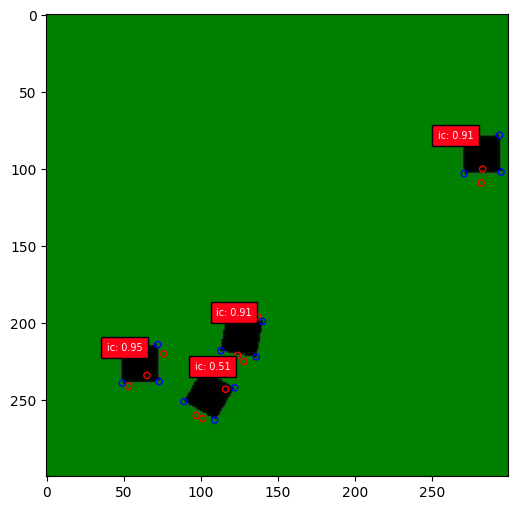

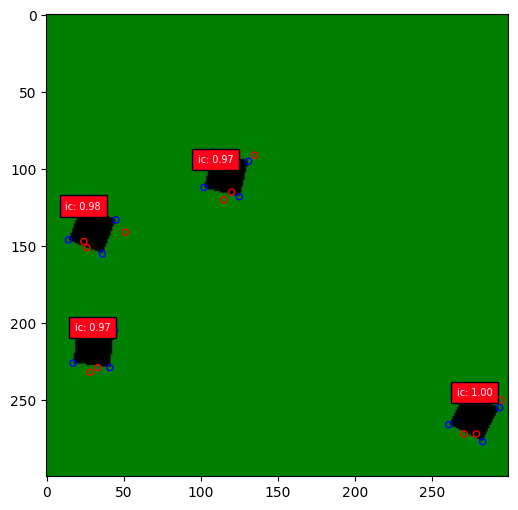

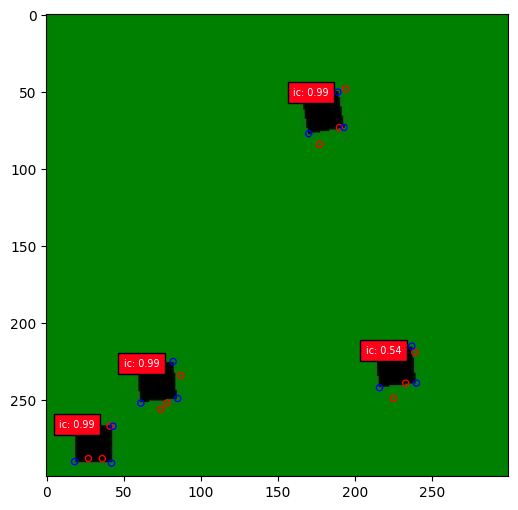

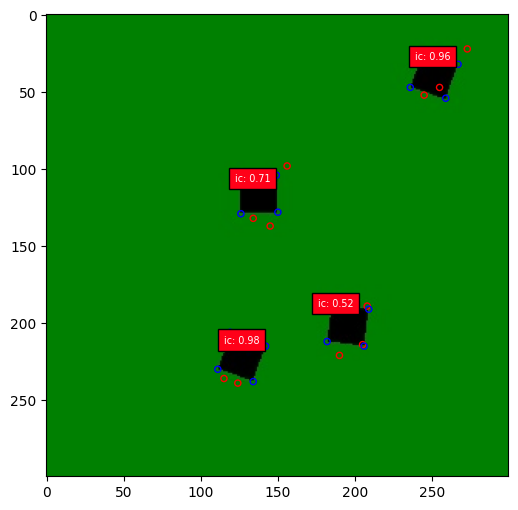

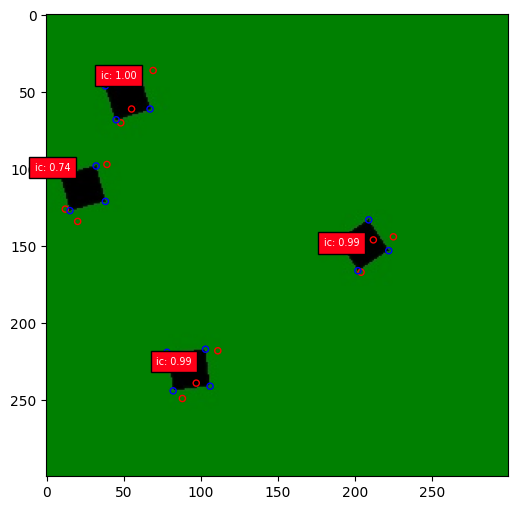

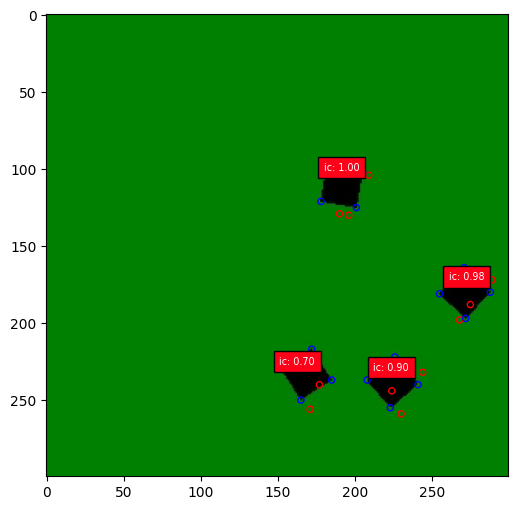

In [13]:
for i in range(len(decoded_pred[:10])):
    plt.figure(figsize=(10,6))
    plt.imshow(X_test[i])
    current_axis = plt.gca()

    colors = plt.cm.hsv(np.linspace(0, 1, n_classes+1)).tolist() # Set the colors for the bounding boxes
    classes = ['background', 'ic'] # Just so we can print class names onto the image instead of IDs
    
    for label in decoded_pred[i]:
        pred = np.array(label)
        corners = np.reshape(pred[2:], (-1, 2)).astype(int)
        color = colors[int(pred[0])]
        label = '{}: {:.2f}'.format(classes[int(pred[0])], pred[1])
        for points in corners:
            current_axis.add_patch(plt.Circle(tuple(points), 2, fill=False, color='red'))
        current_axis.text(corners[0, 0], corners[0, 1], label, size='x-small', color='white', bbox={'facecolor':color, 'alpha':1.0})
            
    for label in decoded_labels[i]:
        pred = np.array(label)
        corners = np.reshape(pred[2:], (-1, 2)).astype(int)
        color = colors[int(pred[0])]
        label = '{}'.format(classes[int(pred[0])])
        for points in corners:
            current_axis.add_patch(plt.Circle(tuple(points), 2, fill=False, color='blue'))